# Train PPMAE – MARIO Challenge

This notebook provides a training template for the **Patch Progression Masked Autoencoder (PPMAE)** used in the MICCAI 2024 MARIO Challenge.

It follows a simple workflow:
1. load the Task 1 train and validation CSV files
2. build PPMAE dataloaders from `(t0, t1)` image pairs
3. initialize the PPMAE model
4. train and validate with reconstruction loss (MSE)
5. save the best checkpoint
6. visualize qualitative predictions

We employed data from Task 1 with image at time `t0` as input and image at time `t1` as target (ground truth).

We assume all OCT images are already preprocessed (OCTIP) to accelerate the training process. In this example, we used orignal images.


## 1. Imports and environment setup

In [2]:
import os
import sys
import random
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
import torchvision.transforms as T

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm.notebook import tqdm

from pathlib import Path
# Add the project root to PYTHONPATH 
PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

from utils.mae_model import PatchProgressionAutoencoderViT

In [3]:
# Set a fixed random seed for reproducibility.
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [4]:
# Select the device used for training.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## 2. Training configuration

In [5]:
# Define the training configuration used in this notebook.
TRAIN_CONFIG = {
    "train_csv_path": "../data/Task_1/df_task1_train.csv",  # path to change 
    "val_csv_path": "../data/Task_1/df_task1_val.csv",  # path to change 
    "train_data_root": "/media/pzhang/Lacie/pzhang/data/MARIO/Task_1/train/",  # path to change 
    "val_data_root": "/media/pzhang/Lacie/pzhang/data/MARIO/Task_1/val/",  # path to change 
    "train_batch_size": 16,
    "val_batch_size": 1,
    "num_workers": 4,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "num_epochs": 10,
    "mask_ratio": 0.25,
    "results_dir": "ppmae_output",
    "experiment_name": "ppmae_vit_large",
    "image_size": (224, 224),
}

## 3. Data loading

In [6]:
# Load the Task 1 train and validation CSV files used to build (t0, t1) image pairs.

df_train = pd.read_csv(TRAIN_CONFIG["train_csv_path"])[:1000] # subsampling for experiment
df_val = pd.read_csv(TRAIN_CONFIG["val_csv_path"])[:100] # subsampling for experiment

print("Train size:", len(df_train))
print("Validation size:", len(df_val))

display(df_train.head())
display(df_val.head())

Train size: 1000
Validation size: 100


,id_patient,side_eye,BScan,image_at_ti,image_at_ti+1,label,split_type,LOCALIZER_at_ti+1,LOCALIZER_at_ti,sex,age_at_ti+1,age_at_ti,num_current_visit_at_i+1,num_current_visit_at_i,delta_t,case
0,1,OD,2,E4521FF0.png,7AF1FF40.png,0,train,7A2E8830.png,E395D4D0.png,F,84,83,3,1,119,1
1,1,OD,3,E44AF400.png,7AE88960.png,0,train,7A2E8830.png,E395D4D0.png,F,84,83,3,1,119,2
2,1,OD,4,E4417E20.png,7ADEEC70.png,0,train,7A2E8830.png,E395D4D0.png,F,84,83,3,1,119,3
3,1,OD,5,E43A5230.png,7AD7E790.png,0,train,7A2E8830.png,E395D4D0.png,F,84,83,3,1,119,4
4,1,OD,6,E42E6B50.png,7ACE4AA0.png,0,train,7A2E8830.png,E395D4D0.png,F,84,83,3,1,119,5


,id_patient,side_eye,BScan,image_at_ti,image_at_ti+1,label,split_type,LOCALIZER_at_ti+1,LOCALIZER_at_ti,sex,age_at_ti+1,age_at_ti,num_current_visit_at_i+1,num_current_visit_at_i,delta_t,case
0,3,OS,2,B3944840.png,AA8E1A00.png,1,val,A9D689D0.png,B2EB0FF0.png,M,81,80,2,1,28,1170
1,3,OS,3,B38D4360.png,AA86EE10.png,1,val,A9D689D0.png,B2EB0FF0.png,M,81,80,2,1,28,1171
2,3,OS,4,B3813570.png,AA7D7830.png,1,val,A9D689D0.png,B2EB0FF0.png,M,81,80,2,1,28,1172
3,3,OS,5,B37A3090.png,AA73DB40.png,1,val,A9D689D0.png,B2EB0FF0.png,M,81,80,2,1,28,1173
4,3,OS,6,B37304A0.png,AA6A6560.png,1,val,A9D689D0.png,B2EB0FF0.png,M,81,80,2,1,28,1174


In [7]:
# ImageNet normalization 
imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std = np.array([0.229, 0.224, 0.225])

In [8]:
# lightweight PPMAE dataset using (t0, t1) pairs from the Task 1 CSV files.
class PPMAE_Dataset(Dataset):
    def __init__(self, df, root_dir, image_size=(224, 224), mode="train"):
        self.samples = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.image_size = image_size
        self.mode = mode

        # PPMAE training augmentations
        self.train_transform = T.Compose([
            T.RandomResizedCrop(image_size[0], scale=(0.8, 1.0)),
            T.RandomHorizontalFlip(p=0.5),
        ])

        self.eval_transform = T.Resize(image_size)

    def __len__(self):
        return len(self.samples)

    def _load_image(self, image_path):
        image = cv2.imread(image_path, 0)
        if image is None:
            raise ValueError(f"Could not read image: {image_path}")
        return Image.fromarray(image)

    def _prepare_image(self, image):
        image = np.array(image).astype(np.float32) / 255.0
        image = np.expand_dims(image, axis=-1)
        image = np.repeat(image, 3, axis=-1)

        # ImageNet normalization
        image = image - imagenet_mean
        image = image / imagenet_std

        x = torch.tensor(image)
        x = torch.einsum("hwc->chw", x).float()
        return x

    def __getitem__(self, idx):
        sample = self.samples.iloc[idx]

        path_t0 = os.path.join(self.root_dir, sample["image_at_ti"])
        path_t1 = os.path.join(self.root_dir, sample["image_at_ti+1"])

        img_t0 = self._load_image(path_t0)
        img_t1 = self._load_image(path_t1)

        if self.mode == "train":
            # Use same random seed so t0 and t1 get the same spatial augmentation
            seed = torch.randint(0, 1_000_000, (1,)).item()

            random.seed(seed)
            torch.manual_seed(seed)
            img_t0 = self.train_transform(img_t0)

            random.seed(seed)
            torch.manual_seed(seed)
            img_t1 = self.train_transform(img_t1)
        else:
            img_t0 = self.eval_transform(img_t0)
            img_t1 = self.eval_transform(img_t1)

        x_t0 = self._prepare_image(img_t0)
        x_t1 = self._prepare_image(img_t1)

        return x_t0, x_t1, path_t0, path_t1

In [9]:
# dataset
train_set = PPMAE_Dataset(
    df_train,
    root_dir=TRAIN_CONFIG["train_data_root"],
    image_size=TRAIN_CONFIG["image_size"],
    mode="train",
)

val_set = PPMAE_Dataset(
    df_val,
    root_dir=TRAIN_CONFIG["val_data_root"],
    image_size=TRAIN_CONFIG["image_size"],
    mode="val",
)

print("Train dataset:", len(train_set))
print("Validation dataset:", len(val_set))

Train dataset: 1000
Validation dataset: 100


In [10]:
# Build the dataloaders used during training and validation.

train_loader = DataLoader(
    train_set,
    batch_size=TRAIN_CONFIG["train_batch_size"],
    shuffle=True,
    num_workers=TRAIN_CONFIG["num_workers"],
    pin_memory=True,
)

val_loader = DataLoader(
    val_set,
    batch_size=TRAIN_CONFIG["val_batch_size"],
    shuffle=False,
    num_workers=TRAIN_CONFIG["num_workers"],
    pin_memory=True,
)

In [11]:
# Inspect one batch to verify tensor shapes and paths.
x_t0, x_t1, paths_t0, paths_t1 = next(iter(train_loader))

print("t0 batch shape:", x_t0.shape)
print("t1 batch shape:", x_t1.shape)
print("example t0 path:", paths_t0[0])
print("example t1 path:", paths_t1[0])

t0 batch shape: torch.Size([16, 3, 224, 224])
t1 batch shape: torch.Size([16, 3, 224, 224])
example t0 path: /media/pzhang/Lacie/pzhang/data/MARIO/Task_1/train/7AAA9600.png
example t1 path: /media/pzhang/Lacie/pzhang/data/MARIO/Task_1/train/D3EE1360.png


## 4. Model and optimizer

In [12]:
# Initialize the PPMAE model and move it to the selected device.
model_mae = PatchProgressionAutoencoderViT().to(DEVICE)
model_mae

PatchProgressionAutoencoderViT(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (blocks): ModuleList(
    (0-23): 24 x Block(
      (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=1024, out_features=3072, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=1024, out_features=1024, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (fc2): Linear(in_features=4096,

In [13]:
# Define the optimizer used for PPMAE training.
optimizer = optim.AdamW(
    model_mae.parameters(),
    lr=TRAIN_CONFIG["learning_rate"],
    weight_decay=TRAIN_CONFIG["weight_decay"],
)

## 5. Training and validation functions

The PPMAE model is trained using the reconstruction **mean squared error (MSE)** between the predicted future OCT and the target OCT.

In [14]:
# Define one training epoch using the PPMAE reconstruction MSE returned by the model.
def train_one_epoch(model, loader, optimizer, device, mask_ratio):
    model.train()

    running_mse = 0.0
    running_samples = 0

    pbar = tqdm(loader, desc="Train", leave=False)

    for x_t0, x_t1, _, _ in pbar:
        x_t0 = x_t0.to(device).float()
        x_t1 = x_t1.to(device).float()

        optimizer.zero_grad()

        mse, _, _ = model(x_t0, x_t1, mask_ratio=mask_ratio)
        mse.backward()
        optimizer.step()

        running_mse += mse.item() * x_t0.size(0)
        running_samples += x_t0.size(0)

        pbar.set_postfix({"mse": f"{mse.item():.4f}"})

    epoch_mse = running_mse / running_samples
    return epoch_mse

In [15]:
# Define one validation epoch using the PPMAE reconstruction MSE returned by the model.
@torch.no_grad()
def validate_one_epoch(model, loader, device, mask_ratio):
    model.eval()

    running_mse = 0.0
    running_samples = 0

    pbar = tqdm(loader, desc="Val", leave=False)

    for x_t0, x_t1, _, _ in pbar:
        x_t0 = x_t0.to(device).float()
        x_t1 = x_t1.to(device).float()

        mse, _, _ = model(x_t0, x_t1, mask_ratio=mask_ratio)

        running_mse += mse.item() * x_t0.size(0)
        running_samples += x_t0.size(0)

        pbar.set_postfix({"mse": f"{mse.item():.4f}"})

    epoch_mse = running_mse / running_samples
    return epoch_mse

## 6. Logging and checkpoint setup

In [16]:
# Create the output directory and TensorBoard writer used to store results.
results_path = os.path.join(TRAIN_CONFIG["results_dir"], TRAIN_CONFIG["experiment_name"])
os.makedirs(results_path, exist_ok=True)

best_model_path = os.path.join(results_path, "best_model_loss.pth")
writer = SummaryWriter(log_dir=results_path)

print("Results path:", results_path)

Results path: ppmae_output/ppmae_vit_large


## 7. Training loop

In [17]:
# Run the training loop and save the best checkpoint according to validation MSE.
best_val_mse = float("inf")

for epoch in tqdm(range(TRAIN_CONFIG["num_epochs"]), desc="Epochs"):
    epoch_start = time.time()

    train_mse = train_one_epoch(
        model_mae,
        train_loader,
        optimizer,
        DEVICE,
        TRAIN_CONFIG["mask_ratio"],
    )

    val_mse = validate_one_epoch(
        model_mae,
        val_loader,
        DEVICE,
        TRAIN_CONFIG["mask_ratio"],
    )

    writer.add_scalar("MSE/train", train_mse, epoch)
    writer.add_scalar("MSE/val", val_mse, epoch)

    if val_mse < best_val_mse:
        best_val_mse = val_mse
        torch.save(model_mae.state_dict(), best_model_path)
        print(f"[INFO] New best checkpoint saved at epoch {epoch} with val_mse={val_mse:.4f}")

    print(
        f"Epoch {epoch + 1}/{TRAIN_CONFIG['num_epochs']} | "
        f"train_mse={train_mse:.4f} | "
        f"val_mse={val_mse:.4f} | "
        f"time={time.time() - epoch_start:.1f}s"
    )

writer.close()

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Train:   0%|          | 0/63 [00:00<?, ?it/s]

Val:   0%|          | 0/100 [00:00<?, ?it/s]

[INFO] New best checkpoint saved at epoch 0 with val_mse=0.3591
Epoch 1/10 | train_mse=0.9661 | val_mse=0.3591 | time=17.6s


Train:   0%|          | 0/63 [00:00<?, ?it/s]

...

Val:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 9/10 | train_mse=0.3891 | val_mse=0.2379 | time=16.7s


Train:   0%|          | 0/63 [00:00<?, ?it/s]

Val:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 10/10 | train_mse=0.3727 | val_mse=0.2245 | time=16.7s


## 8. Reload the best checkpoint

In [18]:
# Reload the best PPMAE checkpoint saved during training.
state_dict = torch.load(best_model_path, map_location=DEVICE, weights_only=True)
model_mae.load_state_dict(state_dict)
model_mae.eval()

print("Best checkpoint loaded:", best_model_path)

Best checkpoint loaded: ppmae_output/ppmae_vit_large/best_model_loss.pth


## 9. Qualitative visualization

In [19]:
# Reverse ImageNet normalization for visualization.
def denormalize_for_display(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()

    if x.ndim == 3 and x.shape[0] == 3:
        x = np.transpose(x, (1, 2, 0))

    x = (x * imagenet_std + imagenet_mean)
    x = np.clip(x, 0, 1)

    # keep middle channel for grayscale display
    x = x[:, :, 1]
    return x

# Define a helper function to visualize the masked input, prediction, and ground truth.
@torch.no_grad()
def visualize_ppmae_example(model, dataset, index=0, device="cpu", mask_ratio=0.25):
    x_t0, x_t1, path_t0, path_t1 = dataset[index]

    x_t0 = x_t0.unsqueeze(0).to(device).float()
    x_t1 = x_t1.unsqueeze(0).to(device).float()

    loss, pred, mask = model(x_t0, x_t1, mask_ratio=mask_ratio)

    x_patch = model.patchify(x_t0).float()
    x_patch_masked = x_patch.clone()

    # predicted reconstruction
    x_patch[mask == 0] = pred
    x_rec = model.unpatchify(x_patch)
    x_rec = x_rec.squeeze(0)

    # masked input visualization
    mean_val = x_patch_masked.mean()
    x_patch_masked[mask == 0] = mean_val
    x_masked = model.unpatchify(x_patch_masked)
    x_masked = x_masked.squeeze(0)

    t0 = denormalize_for_display(x_t0.squeeze(0))
    t0_masked = denormalize_for_display(x_masked)
    pred_t1 = denormalize_for_display(x_rec)
    t1 = denormalize_for_display(x_t1.squeeze(0))

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    titles = ["Image T0", "Image T0 Masked", "Predict Image", "Image T1 Original"]
    images = [t0, t0_masked, pred_t1, t1]

    for i in range(4):
        axes[i].imshow(images[i], cmap="gray")
        axes[i].set_title(titles[i], fontsize=11)
        axes[i].axis("off")

    fig.suptitle(f"index={index} | mse={loss.item():.4f}", fontsize=13)
    plt.tight_layout()
    plt.show()

    print("t0 path:", path_t0)
    print("t1 path:", path_t1)

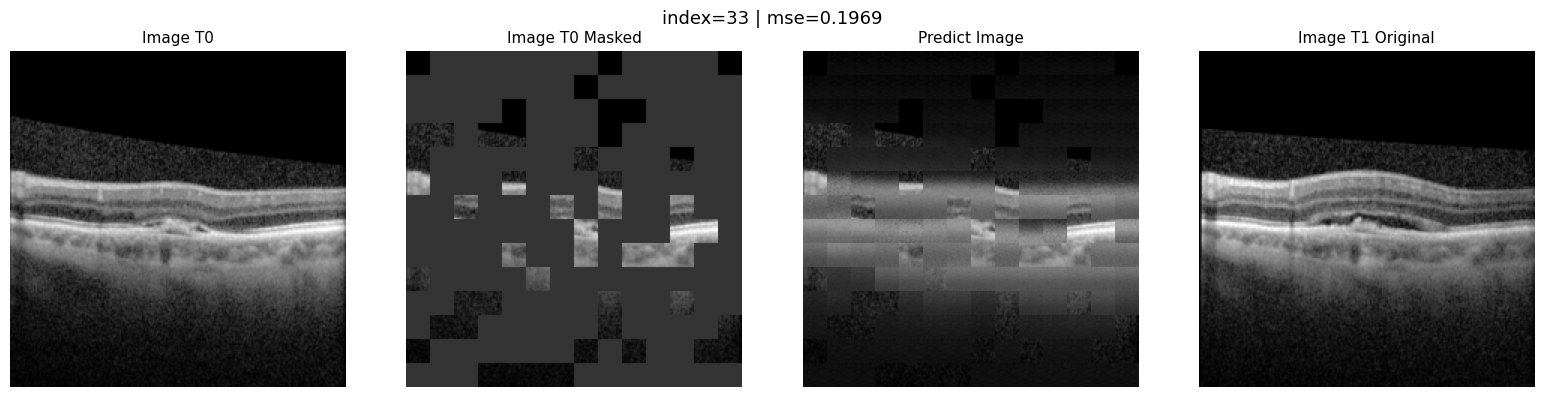

t0 path: /media/pzhang/Lacie/pzhang/data/MARIO/Task_1/val/AA120C30.png
t1 path: /media/pzhang/Lacie/pzhang/data/MARIO/Task_1/val/A05B0480.png


In [20]:
# Visualize one validation example using the best checkpoint.
visualize_ppmae_example(
    model_mae,
    val_set,
    index=33,
    device=DEVICE,
    mask_ratio=TRAIN_CONFIG["mask_ratio"],
)